<a href="https://colab.research.google.com/github/jananiksaagash-rgb/AppliedAI/blob/main/Ex9b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload your image


Saving Screenshot 2026-03-30 152444.png to Screenshot 2026-03-30 152444.png


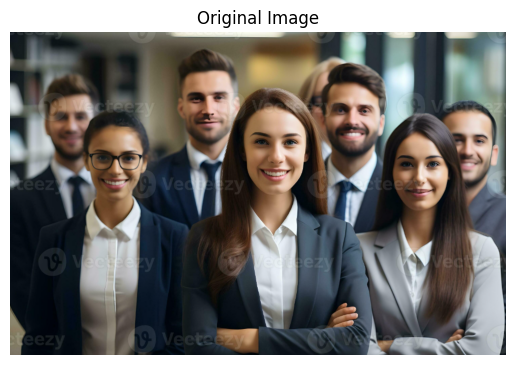

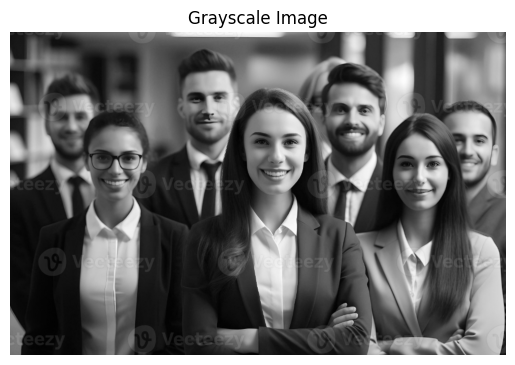

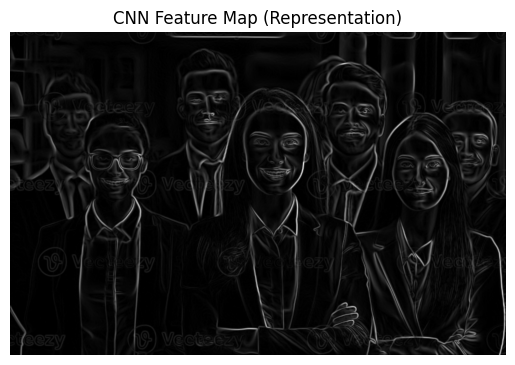

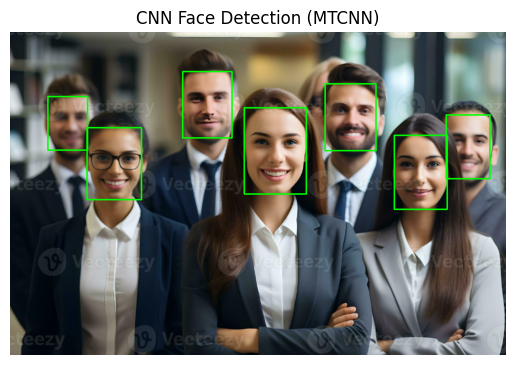

Number of faces detected: 7


In [16]:
# Install (run once)
!pip install mtcnn opencv-python matplotlib -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN
from google.colab import files

# ===============================
# Upload Image
# ===============================
print("Upload your image")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# ===============================
# Read Image
# ===============================
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ===============================
#  Original Image
# ===============================
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

# ===============================
#  Grayscale Image
# ===============================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# ===============================
#  CNN Feature Representation
# ===============================
# Simulate CNN feature map using edge + normalization
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)

feature_map = cv2.magnitude(sobelx, sobely)

# Normalize for better display
feature_map = (feature_map - feature_map.min()) / (feature_map.max() - feature_map.min())

plt.imshow(feature_map, cmap='gray')
plt.title("CNN Feature Map (Representation)")
plt.axis("off")
plt.show()

# ===============================
#  MTCNN Face Detection
# ===============================
detector = MTCNN()
faces = detector.detect_faces(img_rgb)

# Draw bounding boxes
output = img_rgb.copy()
for face in faces:
    x, y, width, height = face['box']
    cv2.rectangle(output, (x, y), (x+width, y+height), (0,255,0), 2)

# ===============================
#  Final Output
# ===============================
plt.imshow(output)
plt.title("CNN Face Detection (MTCNN)")
plt.axis("off")
plt.show()

# Count
print("Number of faces detected:", len(faces))